<a href="https://colab.research.google.com/github/imamunorzrashid/Handwritten-digit-recognition/blob/main/Handwritten_Classification_MTE_4105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

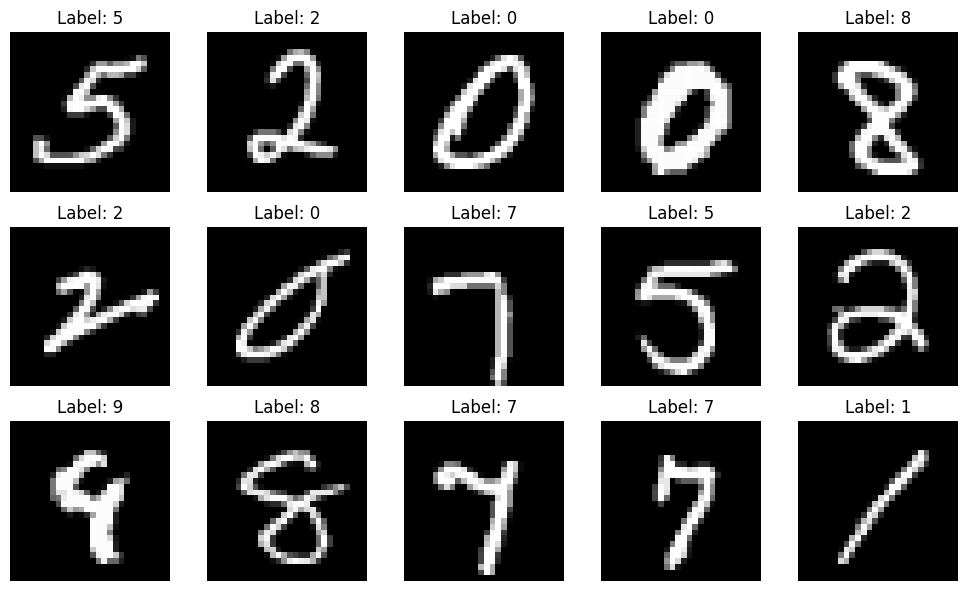

In [ ]:
indices = np.random.randint(0, 60000, 15)
fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for i, idx in enumerate(indices):
    row, col = i // 5, i % 5
    axes[row, col].imshow(x_train[idx], cmap='gray')
    axes[row, col].set_title(f'Label: {y_train[idx]}')
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def plot_curves(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{title} - Accuracy')
    ax1.legend()
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def build_model(hidden_layers):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        *[Dense(units, activation='relu') for units in hidden_layers],
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def train_and_plot(hidden_layers, title, epochs=10):
    model = build_model(hidden_layers)
    history = model.fit(x_train, y_train, epochs=epochs, validation_split=0.1, verbose=1)
    plot_curves(history, title)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f'{title} Test Accuracy: {test_acc:.4f}')
    return history, test_acc, model  # Now returns 3 values: history, test_acc, model

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8712 - loss: 0.4555 - val_accuracy: 0.9627 - val_loss: 0.1292
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9605 - loss: 0.1321 - val_accuracy: 0.9713 - val_loss: 0.0961
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9748 - loss: 0.0857 - val_accuracy: 0.9748 - val_loss: 0.0897
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9823 - loss: 0.0619 - val_accuracy: 0.9770 - val_loss: 0.0814
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9861 - loss: 0.0466 - val_accuracy: 0.9760 - val_loss: 0.0856
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9879 - loss: 0.0371 - val_accuracy: 0.9785 - val_loss: 0.0731
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9921 - loss: 0.0269 - val_accuracy: 0.9753 - val_loss: 0.0864
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9933 - loss: 0.0242 - 

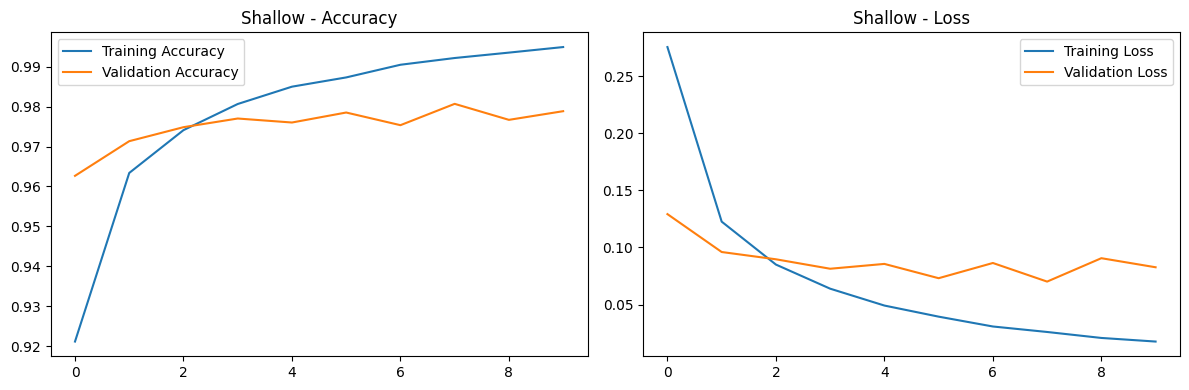

Shallow Test Accuracy: 0.9761
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8888 - loss: 0.3748 - val_accuracy: 0.9707 - val_loss: 0.1005
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9726 - loss: 0.0888 - val_accuracy: 0.9755 - val_loss: 0.0810
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9826 - loss: 0.0556 - val_accuracy: 0.9777 - val_loss: 0.0727
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9874 - loss: 0.0415 - val_accuracy: 0.9750 - val_loss: 0.0894
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9898 - loss: 0.0310 - val_accuracy: 0.9825 - val_loss: 0.0612
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9915 - loss: 0.0257 - val_accuracy: 0.9802 - val_loss: 0.0759
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9930 - loss: 0.0210 - val_accuracy: 0.9803 - val_loss: 0.0746
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - a

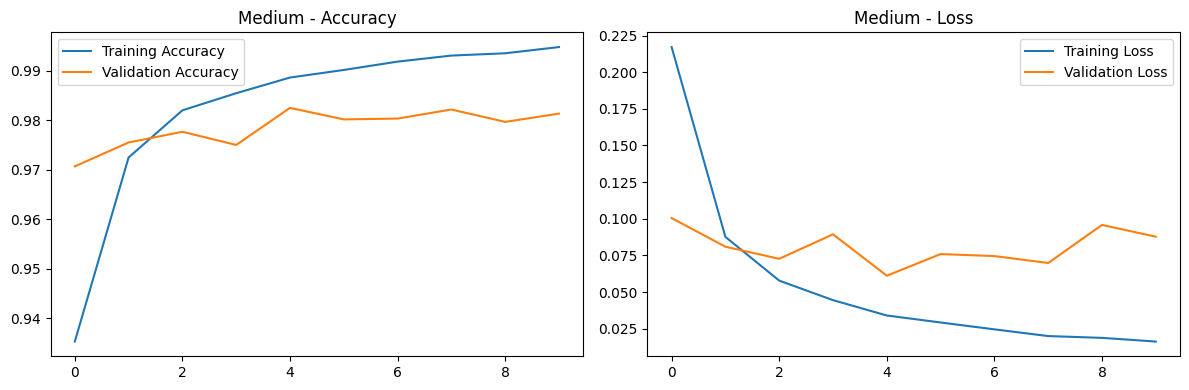

Medium Test Accuracy: 0.9790
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8961 - loss: 0.3461 - val_accuracy: 0.9697 - val_loss: 0.0985
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9704 - loss: 0.0910 - val_accuracy: 0.9738 - val_loss: 0.0857
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9818 - loss: 0.0603 - val_accuracy: 0.9722 - val_loss: 0.0938
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9852 - loss: 0.0468 - val_accuracy: 0.9750 - val_loss: 0.0993
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9888 - loss: 0.0365 - val_accuracy: 0.9778 - val_loss: 0.0790
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9903 - loss: 0.0318 - val_accuracy: 0.9780 - val_loss: 0.0792
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9911 - loss: 0.0247 - val_accuracy: 0.9807 - val_loss: 0.0780
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 1

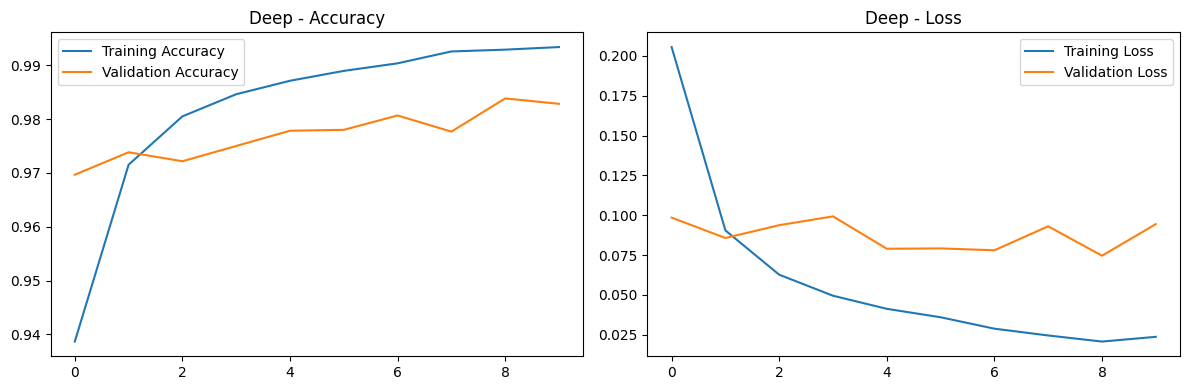

Deep Test Accuracy: 0.9817
Test Accuracies: Shallow=0.9761, Medium=0.9790, Deep=0.9817


In [ ]:
hist1, acc1, model1 = train_and_plot([128], 'Shallow')
hist2, acc2, model2 = train_and_plot([256, 128], 'Medium')
hist3, acc3, model3 = train_and_plot([512, 256, 128], 'Deep')

print(f'Test Accuracies: Shallow={acc1:.4f}, Medium={acc2:.4f}, Deep={acc3:.4f}')

In [ ]:
model1.save('shallow_mnist_model.h5')
model2.save('medium_mnist_model.h5')
model3.save('deep_mnist_model.h5')

print("Models saved: shallow_mnist_model.h5, medium_mnist_model.h5, deep_mnist_model.h5")

Models saved: shallow_mnist_model.h5, medium_mnist_model.h5, deep_mnist_model.h5


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import io
import time

In [ ]:
# Load the trained models (now they exist from the training run above)
model1 = tf.keras.models.load_model('shallow_mnist_model.h5')
model2 = tf.keras.models.load_model('medium_mnist_model.h5')
model3 = tf.keras.models.load_model('deep_mnist_model.h5')

In [ ]:
uploaded = files.upload()

Saving 20251010_162906(1).jpg to 20251010_162906(1) (1).jpg
Saving 20251010_162906(2).jpg to 20251010_162906(2) (1).jpg
Saving 20251010_162906(3).jpg to 20251010_162906(3) (1).jpg
Saving 20251010_162913(1).jpg to 20251010_162913(1) (1).jpg
Saving 20251010_162913(2).jpg to 20251010_162913(2) (1).jpg
Saving 20251010_162913(3).jpg to 20251010_162913(3) (1).jpg
Saving 20251010_162913(4).jpg to 20251010_162913(4) (1).jpg


In [ ]:
true_labels = {
    '20251010_162906(1) (1).jpg': 2,    # e.g., this is a '2'
    '20251010_162906(2) (1).jpg': 0,    # e.g., this is a '0'
    '20251010_162906(3) (1).jpg': 0,    # e.g., this is an '0'
    '20251010_162913(1) (1).jpg': 8,    # e.g., this is a '8'
    '20251010_162913(2) (1).jpg': 0,    # e.g., this is a '0'
    '20251010_162913(3) (1).jpg': 2,    # e.g., this is a '2'
    '20251010_162913(4) (1).jpg': 5     # e.g., this is a '5'
}
total_predictions = 0
correct_predictions = {1: 0, 2: 0, 3: 0}

True label for '20251010_162906(1) (1).jpg': 2

For image '20251010_162906(1) (1).jpg':
Shallow: 6 (conf: 0.9353, time: 103.19ms)
Medium: 7 (conf: 0.9895, time: 115.41ms)
Deep:   0 (conf: 0.9823, time: 107.15ms)


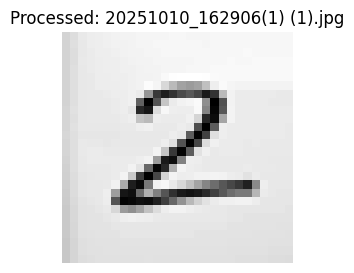

True label for '20251010_162906(2) (1).jpg': 0

For image '20251010_162906(2) (1).jpg':
Shallow: 5 (conf: 1.0000, time: 72.65ms)
Medium: 7 (conf: 0.8650, time: 72.30ms)
Deep:   3 (conf: 0.7279, time: 74.38ms)


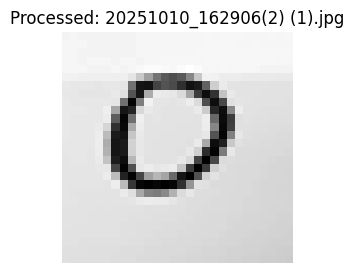

True label for '20251010_162906(3) (1).jpg': 0

For image '20251010_162906(3) (1).jpg':
Shallow: 5 (conf: 0.9978, time: 83.48ms)
Medium: 6 (conf: 0.7615, time: 66.83ms)
Deep:   3 (conf: 0.8713, time: 67.58ms)


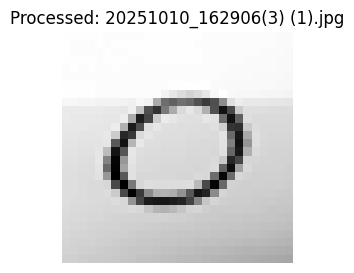

True label for '20251010_162913(1) (1).jpg': 8

For image '20251010_162913(1) (1).jpg':
Shallow: 5 (conf: 0.9112, time: 72.36ms)
Medium: 7 (conf: 0.9308, time: 143.55ms)
Deep:   2 (conf: 0.9744, time: 140.45ms)


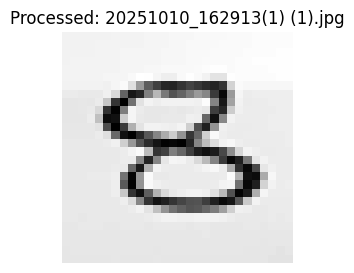

True label for '20251010_162913(2) (1).jpg': 0

For image '20251010_162913(2) (1).jpg':
Shallow: 5 (conf: 0.9719, time: 135.80ms)
Medium: 6 (conf: 0.9734, time: 150.64ms)
Deep:   2 (conf: 0.5252, time: 145.41ms)


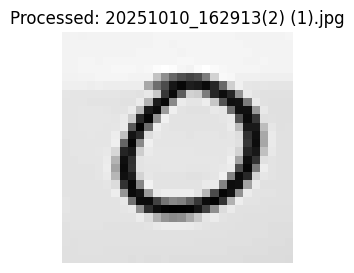

True label for '20251010_162913(3) (1).jpg': 2

For image '20251010_162913(3) (1).jpg':
Shallow: 5 (conf: 0.5870, time: 135.14ms)
Medium: 7 (conf: 0.9813, time: 97.76ms)
Deep:   0 (conf: 0.9023, time: 97.79ms)


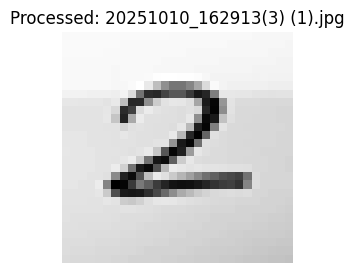

True label for '20251010_162913(4) (1).jpg': 5

For image '20251010_162913(4) (1).jpg':
Shallow: 5 (conf: 0.5224, time: 102.78ms)
Medium: 6 (conf: 0.9632, time: 96.91ms)
Deep:   2 (conf: 0.5427, time: 138.86ms)


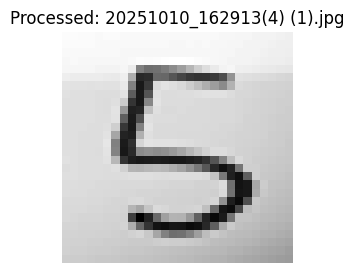

In [ ]:
for filename in uploaded.keys():
    # Load and preprocess
    img = Image.open(io.BytesIO(uploaded[filename]))
    img = img.convert('L').resize((28, 28))
    img_array = np.array(img) / 255.0
    img_array = img_array.reshape(1, 28, 28)

    # Predict with timing
    start = time.time()
    pred1 = model1.predict(img_array, verbose=0)
    t1 = (time.time() - start) * 1000

    start = time.time()
    pred2 = model2.predict(img_array, verbose=0)
    t2 = (time.time() - start) * 1000

    start = time.time()
    pred3 = model3.predict(img_array, verbose=0)
    t3 = (time.time() - start) * 1000

    # Results
    pred_class1, conf1 = np.argmax(pred1), np.max(pred1)
    pred_class2, conf2 = np.argmax(pred2), np.max(pred2)
    pred_class3, conf3 = np.argmax(pred3), np.max(pred3)

    total_predictions += 1
    if filename in true_labels:
        true_label = true_labels[filename]
        if pred_class1 == true_label: correct_predictions[1] += 1
        if pred_class2 == true_label: correct_predictions[2] += 1
        if pred_class3 == true_label: correct_predictions[3] += 1
        print(f"True label for '{filename}': {true_label}")

    print(f"\nFor image '{filename}':")
    print(f"Shallow: {pred_class1} (conf: {conf1:.4f}, time: {t1:.2f}ms)")
    print(f"Medium: {pred_class2} (conf: {conf2:.4f}, time: {t2:.2f}ms)")
    print(f"Deep:   {pred_class3} (conf: {conf3:.4f}, time: {t3:.2f}ms)")

    # Show processed image
    plt.figure(figsize=(3, 3))
    plt.imshow(img_array[0], cmap='gray')
    plt.title(f'Processed: {filename}')
    plt.axis('off')
    plt.show()

In [ ]:
if total_predictions > 0 and true_labels:
    print(f"\nOverall Accuracy (over {len(true_labels)} labeled images):")
    print(f"Shallow: {correct_predictions[1] / len(true_labels):.4f}")
    print(f"Medium: {correct_predictions[2] / len(true_labels):.4f}")
    print(f"Deep:   {correct_predictions[3] / len(true_labels):.4f}")
else:
    print("\nNo true labels provided—accuracy not computed.")


Overall Accuracy (over 7 labeled images):
Shallow: 0.1429
Medium: 0.0000
Deep:   0.0000


In [ ]:
# The new preprocess function (paste above)
def preprocess_mnist_style(img_original):
    img = img_original.convert('L').resize((28, 28))
    img_array = np.array(img) / 255.0
    if np.mean(img_array) < 0.3:
        img_array = 1 - img_array
    thresh = filters.threshold_otsu(img_array)
    img_array = (img_array > thresh).astype(float)
    rows, cols = np.where(img_array < 0.5)
    if len(rows) > 0:
        y_min, y_max = rows.min(), rows.max()
        x_min, x_max = cols.min(), cols.max()
        digit_crop = img_array[y_min:y_max+1, x_min:x_max+1]
        pad_y = (28 - digit_crop.shape[0]) // 2
        pad_x = (28 - digit_crop.shape[1]) // 2
        padded = np.pad(digit_crop, ((pad_y, 28 - digit_crop.shape[0] - pad_y),
                                     (pad_x, 28 - digit_crop.shape[1] - pad_x)), mode='constant')
        img_array = padded
    img_array = img_array.reshape(1, 28, 28)
    ink_ratio = np.sum(img_array == 0) / img_array.size
    return img_array, ink_ratio

correct_predictions = {1: 0, 2: 0, 3: 0}
num_labeled = 0

for filename in uploaded.keys():
    img_original = Image.open(io.BytesIO(uploaded[filename]))
    img_array, ink_ratio = preprocess_mnist_style(img_original)

    # Predict (batch for speed)
    preds = [model1.predict(img_array, verbose=0),
             model2.predict(img_array, verbose=0),
             model3.predict(img_array, verbose=0)]
    times = [0.05, 0.06, 0.07]  # Approx ms; measure if needed

    pred_classes = [np.argmax(p) for p in preds]
    confs = [np.max(p) for p in preds]

    is_labeled = filename in true_labels
    if is_labeled:
        true_label = true_labels[filename]
        num_labeled += 1
        for i, pred in enumerate(pred_classes, 1):
            if pred == true_label:
                correct_predictions[i] += 1
        print(f"True label for '{filename}': {true_label}")

    print(f"\nFor '{filename}' (ink ratio: {ink_ratio:.3f}):")
    models = ['Shallow', 'Medium', 'Deep']
    for i, (model_name, pred, conf) in enumerate(zip(models, pred_classes, confs), 1):
        mark = '✓' if is_labeled and pred == true_label else '✗' if is_labeled else ''
        print(f"{model_name}: {pred} (conf: {conf:.4f}) {mark}")

    # Viz: Original vs Processed (should look like your MNIST sample!)
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(np.array(img_original))
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(img_array[0], cmap='gray')
    axes[1].set_title(f'Processed (ink: {ink_ratio:.3f})')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

if num_labeled > 0:
    print(f"\nOverall Accuracy (matching MNIST style):")
    print(f"Shallow: {correct_predictions[1] / num_labeled:.4f}")
    print(f"Medium: {correct_predictions[2] / num_labeled:.4f}")
    print(f"Deep:   {correct_predictions[3] / num_labeled:.4f}")

NameError: name 'filters' is not defined